In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error)
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../data/features.csv')
print("Loaded:", df.shape)

Loaded: (3049823, 34)


In [2]:
# Use station 153 (maps to Andheri in Mumbai)
station_df = df[df['station_code']==153].copy()
station_df = station_df.sort_values('timestamp')
print("Station rows:", len(station_df))

FEATURES = [
    'hour','day_of_week','month',
    'is_weekend','is_peak_hour',
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'is_festival','festival_mult',
    'is_cricket','is_bandh','is_monsoon',
    'lag_1','lag_2','lag_3','lag_4','lag_8','lag_24',
    'roll_mean_4','roll_mean_8','roll_mean_24',
    'roll_std_4','roll_std_24',
]

X = station_df[FEATURES].values
y = station_df['people_in'].values

Station rows: 11038


In [3]:
# Time based split
split = int(len(X) * 0.80)

X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

print(f"Train: {len(X_train):,}")
print(f"Test:  {len(X_test):,}")

Train: 8,830
Test:  2,208


In [4]:
model = XGBRegressor(
    n_estimators  = 300,
    max_depth     = 6,
    learning_rate = 0.05,
    subsample     = 0.8,
    random_state  = 42,
    verbosity     = 0
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

print("Training complete")

Training complete


In [5]:
preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs(
    (y_test - preds) / np.clip(y_test, 1, None))) * 100

print("="*40)
print(f"  MAE  : {mae:.1f} passengers")
print(f"  RMSE : {rmse:.1f}")
print(f"  MAPE : {mape:.2f}%")
print("="*40)

  MAE  : 95.2 passengers
  RMSE : 151.7
  MAPE : 15.09%


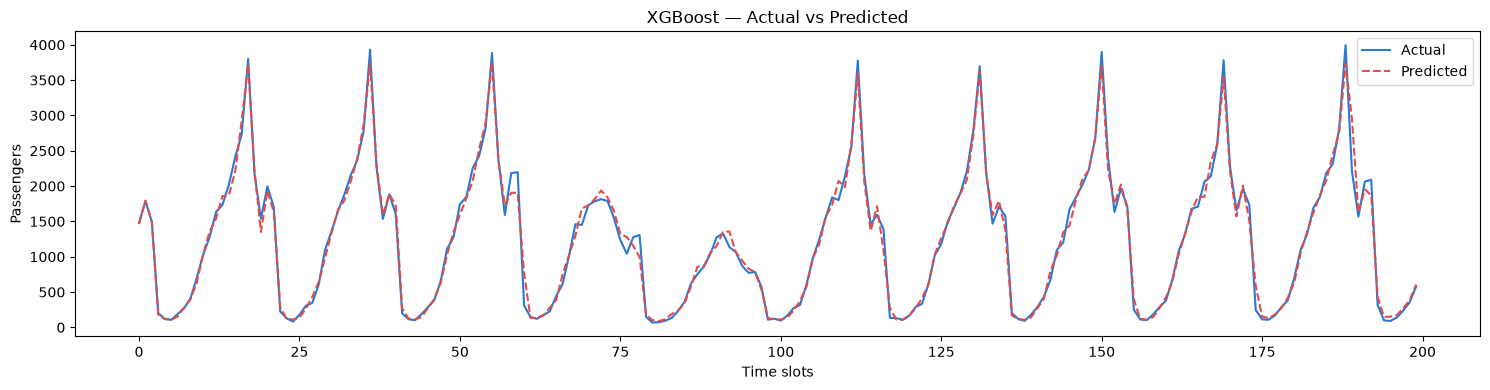

In [6]:
plt.figure(figsize=(15, 4))
plt.plot(y_test[:200],
         label='Actual',    color='#2a78d6')
plt.plot(preds[:200],
         label='Predicted', color='#e24b4a',
         linestyle='--')
plt.title('XGBoost — Actual vs Predicted')
plt.xlabel('Time slots')
plt.ylabel('Passengers')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/xgboost_result.png')
plt.show()

In [7]:
os.makedirs('../models', exist_ok=True)
model.save_model('../models/xgb_model.json')
print("Model saved")

Model saved
